In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
import joblib


In [6]:
# Sample data: hours studied vs scores
data = pd.read_csv('student_study_stress_dataset.csv')

input_matrix = np.array(list(zip(data['Study_hours'], data['Sleep_hours'], data['Stress_level'], data['Attendance'])))
scores = np.array(data['Marks'])
print("Input Matrix:\n", input_matrix)
# print("Data Head:\n", data.head())

Input Matrix:
 [[  4   5   9  95]
 [  5   9   5  78]
 [  3   9   6  85]
 [  5   6   4  62]
 [  5   9  10  78]
 [  2   6   7  79]
 [  3   5   9  91]
 [  3   8   7  66]
 [  3   8   1 100]
 [  5   8   1  92]
 [  4   9   9  99]
 [  3   5   9  98]
 [  5   9   4  77]
 [  2   9   9  99]
 [  4   5   3  60]
 [  2   5   7  70]
 [  4   5   6  87]
 [  5   5   8  84]
 [  1   8   9  82]
 [  4   7   5  90]
 [  2   7   1  89]
 [  5   5   3  94]
 [  4   7  10  66]
 [  1   7   8  75]
 [  1   5   6  85]
 [  3   7   8  61]
 [  3   9   9  60]
 [  2   6   4  71]
 [  4   6   1  64]
 [  4   5   1  96]
 [  3   8  10  91]
 [  4   5   4  68]
 [  4   8   7 100]
 [  1   6   2  94]
 [  3   5   3  78]
 [  5   9   1  75]
 [  3   7   5  62]
 [  5   8   1  79]
 [  1   7   8  83]
 [  2   7   1  92]
 [  4   5   1  83]
 [  1   7   2  70]
 [  4   9   2  67]
 [  2   7   6  95]
 [  2   5   7  97]
 [  1   9   5  99]
 [  2   6   1  79]
 [  5   7   1  94]
 [  2   5   3  84]
 [  4   6   2  94]
 [  4   6   5  84]
 [  4   8  10  8

In [7]:
# Reshape and scale the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(input_matrix)
X_train, X_test, y_train, y_test = train_test_split(x_scaled, scores, test_size=0.2, random_state=42)

In [8]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
#take user input and make prediction
Study_hours_exam = float(input("Enter study hours: "))
Sleep_hours_exam = float(input("Enter sleep hours: "))
Stress_level_exam = float(input("Enter stress level: "))
Attendance_exam = float(input("Enter attendance percentage: "))
input_data = np.array([[Study_hours_exam, Sleep_hours_exam, Stress_level_exam, Attendance_exam]])
input_scaled = scaler.transform(input_data)

In [10]:
#make prediction
predictions = model.predict(input_scaled)
print("Predicted marks:", round(predictions[0], 2))

Predicted marks: 89.82


In [11]:
# Evaluate the model
r2 = model.score(X_test, y_test)
print("R² score:", round(r2, 2))

y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error (MSE):", round(mse, 2))

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error (MAE):", round(mae, 2))


R² score: 0.95
Mean Squared Error (MSE): 8.38
Mean Absolute Error (MAE): 2.13


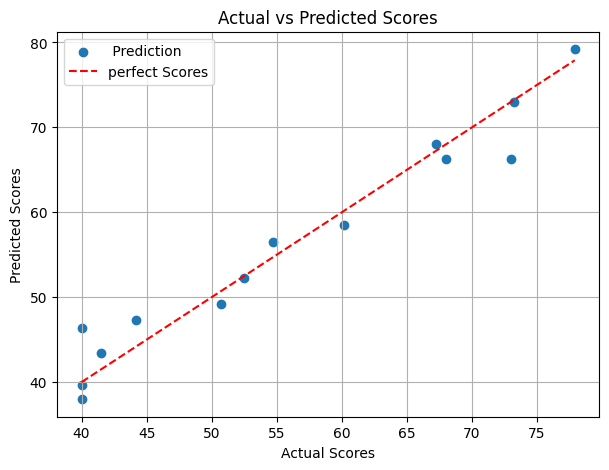

In [12]:
#graph of actual vs predicted
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, colorizer='blue', alpha=1)  

# Perfect prediction line
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         linestyle='--',
         color='red')

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted Scores")
plt.grid()
plt.legend([" Prediction", "perfect Scores"])
plt.show()

In [15]:
# Save the model and scaler
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

NameError: name 'joblib' is not defined